# Vertical Profiles

**Last Updated: May 1, 2026**

**Load the necessary packages**

In [28]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

**Input & Output Directories**

In [29]:
from pathlib import Path

# Base directory (JAXALFA0.1/) — 5 levels above this notebook
BaseDir = Path(__file__).parents[4] if '__file__' in dir() else Path.cwd().parents[4]

# 40x40x40 run
OutputDir1A = BaseDir / 'examples/NBL_A94/runs/40x40x40/output'

# 64x64x64 run
OutputDir2A = BaseDir / 'examples/NBL_A94/runs/64x64x64/output'

# 80x80x80 run
OutputDir3A = BaseDir / 'examples/NBL_A94/runs/80x80x80/output'

# 128x128x128 run
OutputDir4A = BaseDir / 'examples/NBL_A94/runs/128x128x128/output'

**Input Information from the Config File**

In [30]:
# Simulation 1
nz_1 = 40 # number of grid points in z direction

# Simulation 2
nz_2 = 64 # number of grid points in z direction

# Simulation 3
nz_3 = 80 # number of grid points in z direction

# Simulation 4
nz_4 = 128 # number of grid points in z direction

# Common settings across the simulations
l_z = 4000 # domain height (m)
SimTime = 100000  # total simulation time (sec)
OutputInterval = 60 # frequency of output (sec)

# Averaging window
T_start = 70000 # unit: sec
T_end = 100000 # unit: sec

**Derived Variables**

In [31]:
# Half levels for u, v, TH variables
z_1 = np.array([(k + 0.5) * l_z / (nz_1 - 1) for k in range(nz_1)])
z_2 = np.array([(k + 0.5) * l_z / (nz_2 - 1) for k in range(nz_2)])
z_3 = np.array([(k + 0.5) * l_z / (nz_3 - 1) for k in range(nz_3)])
z_4 = np.array([(k + 0.5) * l_z / (nz_4 - 1) for k in range(nz_4)])

# Full levels for fluxes
z_w_1 = np.array([(k) * l_z / (nz_1 - 1) for k in range(nz_1)])
z_w_2 = np.array([(k) * l_z / (nz_2 - 1) for k in range(nz_2)])
z_w_3 = np.array([(k) * l_z / (nz_3 - 1) for k in range(nz_3)])
z_w_4 = np.array([(k) * l_z / (nz_4 - 1) for k in range(nz_4)])

# Averaging indices
T_start_index = int(T_start / OutputInterval) - 1
T_end_index = int(T_end / OutputInterval) - 1

**Function to Load Statistics & Perform Temporal Averaging**

In [32]:
def LoadStatsAverage(StatFiles, T_start_index, T_end_index):
    
    # Initialize lists
    U   = []
    V   = []
    u2  = []
    v2  = []
    w2  = []
    uv  = []
    uw  = []
    vw  = []
    txy = []
    txz = []
    tyz = []
    
    # Process each file
    for file in StatFiles:
        with np.load(file) as data:
            U.append(data['U'])
            V.append(data['V'])
            u2.append(data['u2'])
            v2.append(data['v2'])
            w2.append(data['w2'])
            uv.append(data['uv'])
            uw.append(data['uw'])
            vw.append(data['vw'])
            txy.append(data['txy'])
            txz.append(data['txz'])
            tyz.append(data['tyz'])
    
    # Convert lists to numpy arrays
    U = np.array(U)
    V = np.array(V)
    u2 = np.array(u2)
    v2 = np.array(v2)
    w2 = np.array(w2)
    uv = np.array(uv)
    uw = np.array(uw)
    vw = np.array(vw)
    txy = np.array(txy)
    txz = np.array(txz)
    tyz = np.array(tyz)
    
    # Temporal averaging
    U_avg  = np.mean(U[T_start_index:T_end_index+1,:],axis=0)
    V_avg  = np.mean(V[T_start_index:T_end_index+1,:],axis=0)

    u2_avg  = np.mean(u2[T_start_index:T_end_index+1,:],axis=0)
    v2_avg  = np.mean(v2[T_start_index:T_end_index+1,:],axis=0)
    w2_avg  = np.mean(w2[T_start_index:T_end_index+1,:],axis=0)
    
    uv_avg  = np.mean(uv[T_start_index:T_end_index+1,:],axis=0)
    uw_avg  = np.mean(uw[T_start_index:T_end_index+1,:],axis=0)
    vw_avg  = np.mean(vw[T_start_index:T_end_index+1,:],axis=0)
    
    txy_avg = np.mean(txy[T_start_index:T_end_index+1,:],axis=0)
    txz_avg = np.mean(txz[T_start_index:T_end_index+1,:],axis=0)
    tyz_avg = np.mean(tyz[T_start_index:T_end_index+1,:],axis=0)
    
    return (U_avg, V_avg,  
            u2_avg, v2_avg, w2_avg,  
            uv_avg, uw_avg, vw_avg,  
            txy_avg, txz_avg, tyz_avg)

**Get All Statistics Files in Chronological Order**

In [33]:
def get_stat_files(output_dir):
    files = sorted(
        glob.glob(str(output_dir / 'ALFA_Statistics_Iteration_*.npz')),
        key=lambda x: int(re.search(r'Iteration_(\d+)', x).group(1))
    )
    return files

StatFiles1A = get_stat_files(OutputDir1A)
StatFiles2A = get_stat_files(OutputDir2A)
StatFiles3A = get_stat_files(OutputDir3A)
StatFiles4A = get_stat_files(OutputDir4A)

**Extract Temporally Averaged Statistics**

In [34]:
(U_avg_1A, V_avg_1A,
 u2_avg_1A, v2_avg_1A, w2_avg_1A,
 uv_avg_1A, uw_avg_1A, vw_avg_1A,
 txy_avg_1A, txz_avg_1A, tyz_avg_1A) = LoadStatsAverage(StatFiles1A, T_start_index, T_end_index)

(U_avg_2A, V_avg_2A,
 u2_avg_2A, v2_avg_2A, w2_avg_2A,
 uv_avg_2A, uw_avg_2A, vw_avg_2A,
 txy_avg_2A, txz_avg_2A, tyz_avg_2A) = LoadStatsAverage(StatFiles2A, T_start_index, T_end_index)

(U_avg_3A, V_avg_3A,
 u2_avg_3A, v2_avg_3A, w2_avg_3A,
 uv_avg_3A, uw_avg_3A, vw_avg_3A,
 txy_avg_3A, txz_avg_3A, tyz_avg_3A) = LoadStatsAverage(StatFiles3A, T_start_index, T_end_index)

(U_avg_4A, V_avg_4A,
 u2_avg_4A, v2_avg_4A, w2_avg_4A,
 uv_avg_4A, uw_avg_4A, vw_avg_4A,
 txy_avg_4A, txz_avg_4A, tyz_avg_4A) = LoadStatsAverage(StatFiles4A, T_start_index, T_end_index)

**Plot the profiles**

In [35]:
plt.rcParams.update({
    "text.usetex": True,
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

In [36]:
def plot_profile(x, z, xlabel, ylabel=r"$z$ (m)", linestyle='-k', label=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 6))

    ax.plot(x, z, linestyle, linewidth=2, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)


**Mean velocity profiles and hodograph**

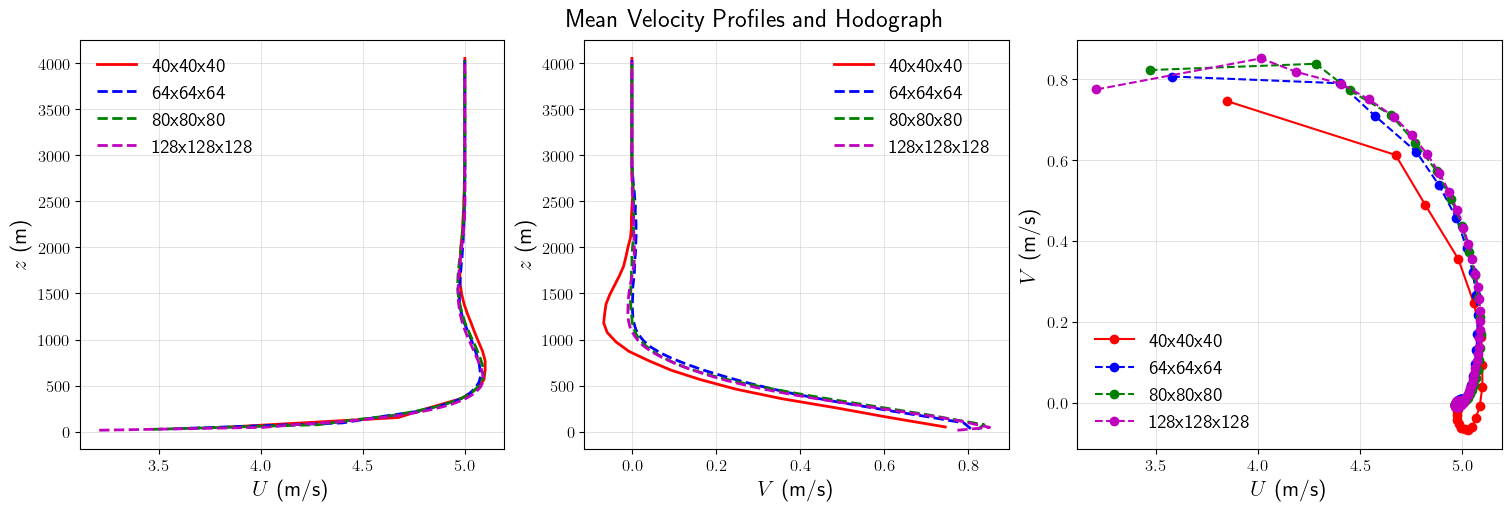

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(U_avg_1A, z_1, xlabel=r"$U$ (m/s)", linestyle='-r',
             ax=axs[0], label='40x40x40')
plot_profile(U_avg_2A, z_2, xlabel=r"$U$ (m/s)", linestyle='--b',
             ax=axs[0], label='64x64x64')
plot_profile(U_avg_3A, z_3, xlabel=r"$U$ (m/s)", linestyle='--g',
             ax=axs[0], label='80x80x80')
plot_profile(U_avg_4A, z_4, xlabel=r"$U$ (m/s)", linestyle='--m',
             ax=axs[0], label='128x128x128')
axs[0].grid()
axs[0].legend(frameon=False)

plot_profile(V_avg_1A, z_1, xlabel=r"$V$ (m/s)", linestyle='-r',
             ax=axs[1], label='40x40x40')
plot_profile(V_avg_2A, z_2, xlabel=r"$V$ (m/s)", linestyle='--b',
             ax=axs[1], label='64x64x64')
plot_profile(V_avg_3A, z_3, xlabel=r"$V$ (m/s)", linestyle='--g',
             ax=axs[1], label='80x80x80')
plot_profile(V_avg_4A, z_4, xlabel=r"$V$ (m/s)", linestyle='--m',
             ax=axs[1], label='128x128x128')
axs[1].grid()
axs[1].legend(frameon=False)

axs[2].plot(U_avg_1A, V_avg_1A, '-or', label='40x40x40')
axs[2].plot(U_avg_2A, V_avg_2A, '--ob', label='64x64x64')
axs[2].plot(U_avg_3A, V_avg_3A, '--og', label='80x80x80')
axs[2].plot(U_avg_4A, V_avg_4A, '--om', label='128x128x128')
axs[2].set_xlabel(r"$U$ (m/s)")
axs[2].set_ylabel(r"$V$ (m/s)")
axs[2].grid()
axs[2].legend(frameon=False)

fig.suptitle("Mean Velocity Profiles and Hodograph", fontsize=18)
plt.show()

**Vertical profiles of velocity variances**

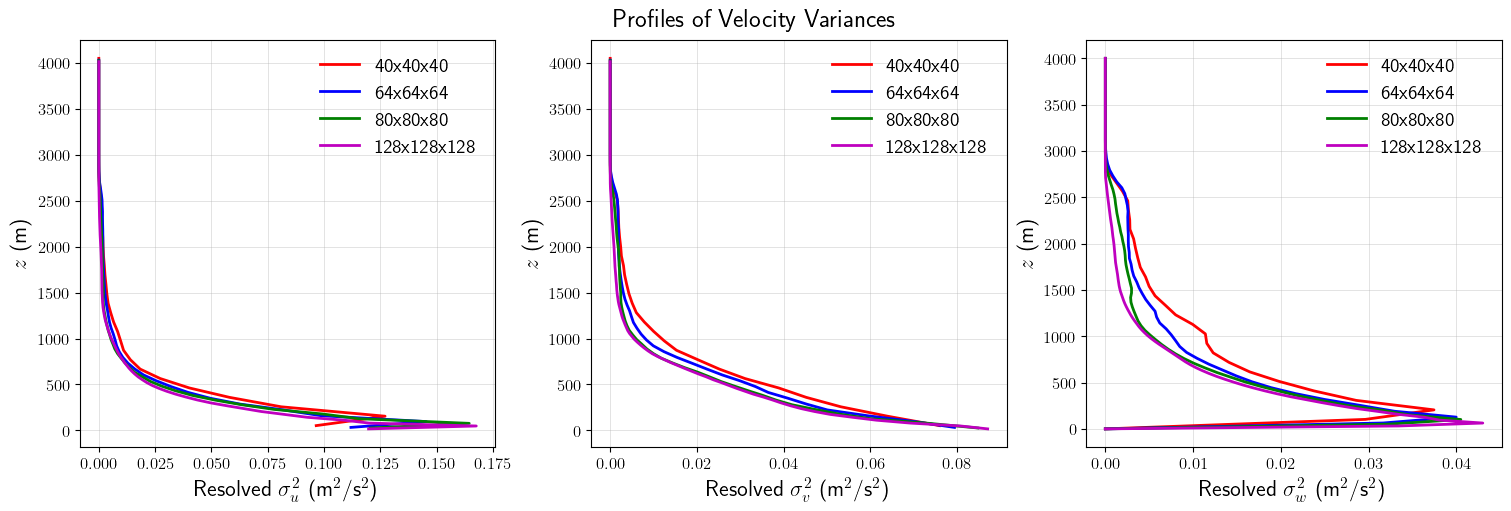

In [38]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(u2_avg_1A, z_1, xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)",
             linestyle='-r', ax=axs[0], label='40x40x40')
plot_profile(u2_avg_2A, z_2, xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)",
             linestyle='-b', ax=axs[0], label='64x64x64')
plot_profile(u2_avg_3A, z_3, xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)",
             linestyle='-g', ax=axs[0], label='80x80x80')
plot_profile(u2_avg_4A, z_4, xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)",
             linestyle='-m', ax=axs[0], label='128x128x128')
axs[0].grid()
axs[0].legend(frameon=False)

plot_profile(v2_avg_1A, z_1, xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)",
             linestyle='-r', ax=axs[1], label='40x40x40')
plot_profile(v2_avg_2A, z_2, xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)",
             linestyle='-b', ax=axs[1], label='64x64x64')
plot_profile(v2_avg_3A, z_3, xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)",
             linestyle='-g', ax=axs[1], label='80x80x80')
plot_profile(v2_avg_4A, z_4, xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)",
             linestyle='-m', ax=axs[1], label='128x128x128')
axs[1].grid()
axs[1].legend(frameon=False)

plot_profile(w2_avg_1A, z_w_1, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)",
             linestyle='-r', ax=axs[2], label='40x40x40')
plot_profile(w2_avg_2A, z_w_2, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)",
             linestyle='-b', ax=axs[2], label='64x64x64')
plot_profile(w2_avg_3A, z_w_3, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)",
             linestyle='-g', ax=axs[2], label='80x80x80')
plot_profile(w2_avg_4A, z_w_4, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)",
             linestyle='-m', ax=axs[2], label='128x128x128')
axs[2].grid()
axs[2].legend(frameon=False)

fig.suptitle("Profiles of Velocity Variances", fontsize=18)
plt.show()

**Vertical profiles of resolved momentum fluxes**

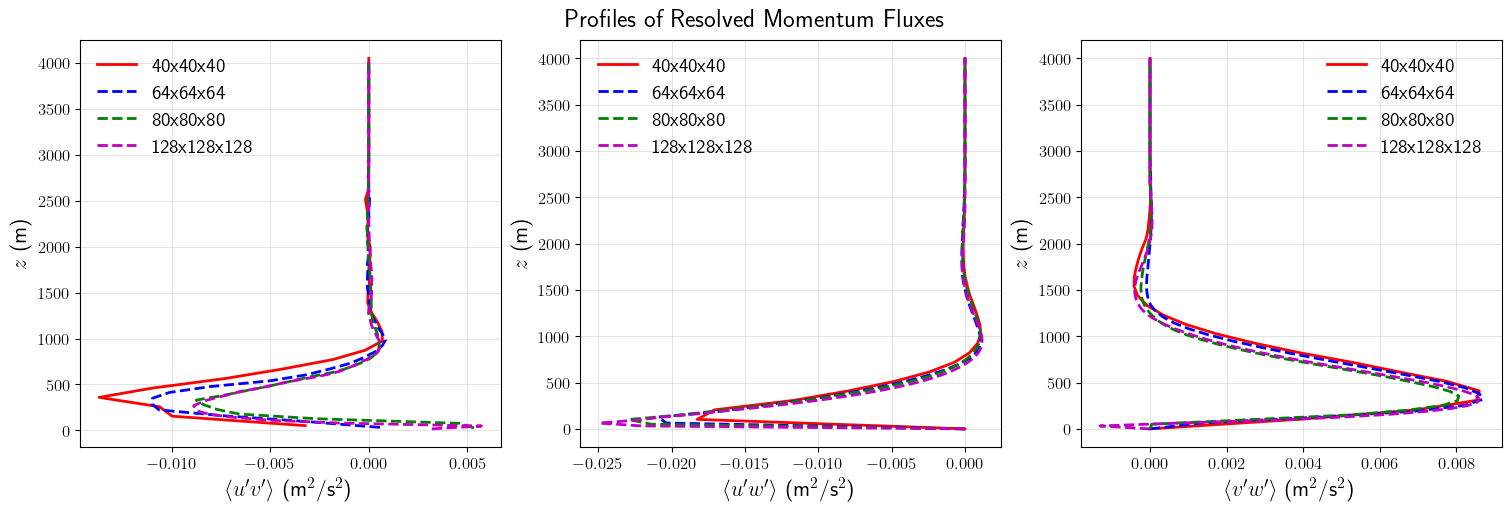

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(uv_avg_1A, z_1, xlabel=r"$\langle u'v' \rangle$ (m$^2$/s$^2$)",
             linestyle='-r', ax=axs[0], label='40x40x40')
plot_profile(uv_avg_2A, z_2, xlabel=r"$\langle u'v' \rangle$ (m$^2$/s$^2$)",
             linestyle='--b', ax=axs[0], label='64x64x64')
plot_profile(uv_avg_3A, z_3, xlabel=r"$\langle u'v' \rangle$ (m$^2$/s$^2$)",
             linestyle='--g', ax=axs[0], label='80x80x80')
plot_profile(uv_avg_4A, z_4, xlabel=r"$\langle u'v' \rangle$ (m$^2$/s$^2$)",
             linestyle='--m', ax=axs[0], label='128x128x128')
axs[0].grid()
axs[0].legend(frameon=False)

plot_profile(uw_avg_1A, z_w_1, xlabel=r"$\langle u'w' \rangle$ (m$^2$/s$^2$)",
             linestyle='-r', ax=axs[1], label='40x40x40')
plot_profile(uw_avg_2A, z_w_2, xlabel=r"$\langle u'w' \rangle$ (m$^2$/s$^2$)",
             linestyle='--b', ax=axs[1], label='64x64x64')
plot_profile(uw_avg_3A, z_w_3, xlabel=r"$\langle u'w' \rangle$ (m$^2$/s$^2$)",
             linestyle='--g', ax=axs[1], label='80x80x80')
plot_profile(uw_avg_4A, z_w_4, xlabel=r"$\langle u'w' \rangle$ (m$^2$/s$^2$)",
             linestyle='--m', ax=axs[1], label='128x128x128')
axs[1].grid()
axs[1].legend(frameon=False)

plot_profile(vw_avg_1A, z_w_1, xlabel=r"$\langle v'w' \rangle$ (m$^2$/s$^2$)",
             linestyle='-r', ax=axs[2], label='40x40x40')
plot_profile(vw_avg_2A, z_w_2, xlabel=r"$\langle v'w' \rangle$ (m$^2$/s$^2$)",
             linestyle='--b', ax=axs[2], label='64x64x64')
plot_profile(vw_avg_3A, z_w_3, xlabel=r"$\langle v'w' \rangle$ (m$^2$/s$^2$)",
             linestyle='--g', ax=axs[2], label='80x80x80')
plot_profile(vw_avg_4A, z_w_4, xlabel=r"$\langle v'w' \rangle$ (m$^2$/s$^2$)",
             linestyle='--m', ax=axs[2], label='128x128x128')
axs[2].grid()
axs[2].legend(frameon=False)

fig.suptitle("Profiles of Resolved Momentum Fluxes", fontsize=18)
plt.show()

**Vertical profiles of SGS stresses**

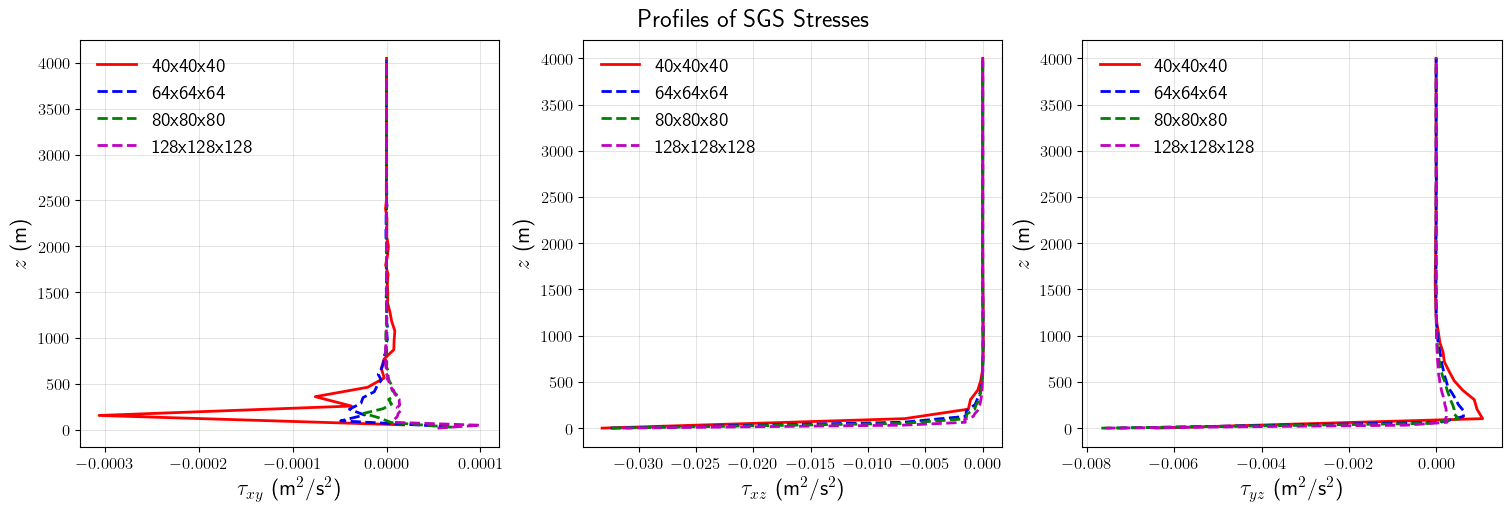

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(txy_avg_1A, z_1, xlabel=r"$\tau_{xy}$ (m$^2$/s$^2$)",
             linestyle='-r', ax=axs[0], label='40x40x40')
plot_profile(txy_avg_2A, z_2, xlabel=r"$\tau_{xy}$ (m$^2$/s$^2$)",
             linestyle='--b', ax=axs[0], label='64x64x64')
plot_profile(txy_avg_3A, z_3, xlabel=r"$\tau_{xy}$ (m$^2$/s$^2$)",
             linestyle='--g', ax=axs[0], label='80x80x80')
plot_profile(txy_avg_4A, z_4, xlabel=r"$\tau_{xy}$ (m$^2$/s$^2$)",
             linestyle='--m', ax=axs[0], label='128x128x128')
axs[0].grid()
axs[0].legend(frameon=False)

plot_profile(txz_avg_1A, z_w_1, xlabel=r"$\tau_{xz}$ (m$^2$/s$^2$)",
             linestyle='-r', ax=axs[1], label='40x40x40')
plot_profile(txz_avg_2A, z_w_2, xlabel=r"$\tau_{xz}$ (m$^2$/s$^2$)",
             linestyle='--b', ax=axs[1], label='64x64x64')
plot_profile(txz_avg_3A, z_w_3, xlabel=r"$\tau_{xz}$ (m$^2$/s$^2$)",
             linestyle='--g', ax=axs[1], label='80x80x80')
plot_profile(txz_avg_4A, z_w_4, xlabel=r"$\tau_{xz}$ (m$^2$/s$^2$)",
             linestyle='--m', ax=axs[1], label='128x128x128')
axs[1].grid()
axs[1].legend(frameon=False)

plot_profile(tyz_avg_1A, z_w_1, xlabel=r"$\tau_{yz}$ (m$^2$/s$^2$)",
             linestyle='-r', ax=axs[2], label='40x40x40')
plot_profile(tyz_avg_2A, z_w_2, xlabel=r"$\tau_{yz}$ (m$^2$/s$^2$)",
             linestyle='--b', ax=axs[2], label='64x64x64')
plot_profile(tyz_avg_3A, z_w_3, xlabel=r"$\tau_{yz}$ (m$^2$/s$^2$)",
             linestyle='--g', ax=axs[2], label='80x80x80')
plot_profile(tyz_avg_4A, z_w_4, xlabel=r"$\tau_{yz}$ (m$^2$/s$^2$)",
             linestyle='--m', ax=axs[2], label='128x128x128')
axs[2].grid()
axs[2].legend(frameon=False)

fig.suptitle("Profiles of SGS Stresses", fontsize=18)
plt.show()